In [1]:
import shap
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from models import *
from datasets import *

In [2]:
dataset = BinaryDataset('Node123_loop')
n_buses = dataset.n_buses
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(20))
feature_names = [f'Bus {i+1}' for i in range(1, n_buses + 1)]

In [3]:
# 初始化模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = CnnClassifier().to(device)
# model = CnnClassifierPairwise().to(device)
# model = FCClassifier(dataset.n_buses).to(device)
# model = SimpleMLPClassifier(dataset.n_buses).to(device)
model = BranchNetworkClassifier(dataset.n_buses).to(device)

model.load_state_dict(torch.load('voltage_cnn_model.pth', weights_only=True))
model.eval()

BranchNetworkClassifier(
  (sub_net): Sequential(
    (0): Linear(in_features=122, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
  )
  (final_classifier): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [4]:
def model_wrapper(x):
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device)
    with torch.no_grad():
        probability = torch.sigmoid(model(x))  # Convert logits to probabilities
        prediction = (probability > 0.5).float()  # Convert to binary labels
    return prediction.cpu().numpy().squeeze()

In [5]:
label_1_samples = []
label_0_samples = []
for data, label in train_dataset:
    if label.item() == 1:  # Filter label 1 samples
        label_1_samples.append(data.numpy())  # Convert to NumPy for SHAP
    else: 
        label_0_samples.append(data.numpy())

# Convert to NumPy array for SHAP compatibility
label_0_samples = np.array(label_0_samples)
label_1_samples = np.array(label_1_samples)

print(label_0_samples.shape)
print(label_1_samples.shape)

(800, 1, 122)
(800, 1, 122)


In [6]:
# Compute mean background from normal (label 0) samples
background_mean = label_0_samples.mean(0)  # Compute mean across samples
# background_mean = torch.tensor(np.zeros_like(background_mean)+0.1, dtype=torch.float32)  # Use zero mean as background

# Ensure at least (n_buses + 1) samples
n_buses = background_mean.shape[-1]
num_background_samples = n_buses + 1  # Ensure SHAP has enough samples

# Expand background by adding small Gaussian noise to the mean values
# background = background_mean.unsqueeze(0).repeat(num_background_samples, 1, 1)  # Repeat mean row [100,1,8]

# Convert to NumPy for SHAP
background = background_mean

""" Check this line of code """
background = np.tile(background, (2, 1))  # Expand background size *2

background.shape

(2, 122)

In [7]:
# Initialize SHAP Explainer
explainer = shap.Explainer(model_wrapper, background, feature_names=feature_names)

2025-03-17 03:57:59.604642: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-17 03:57:59.611248: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742209079.619091   29766 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742209079.621504   29766 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-17 03:57:59.629731: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [8]:
shap_values = explainer(label_1_samples.squeeze())

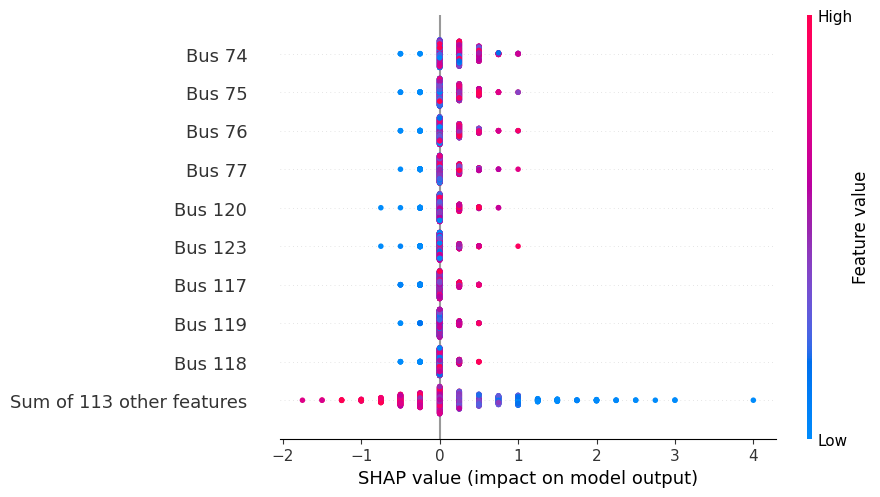

In [9]:
shap.plots.beeswarm(shap_values)

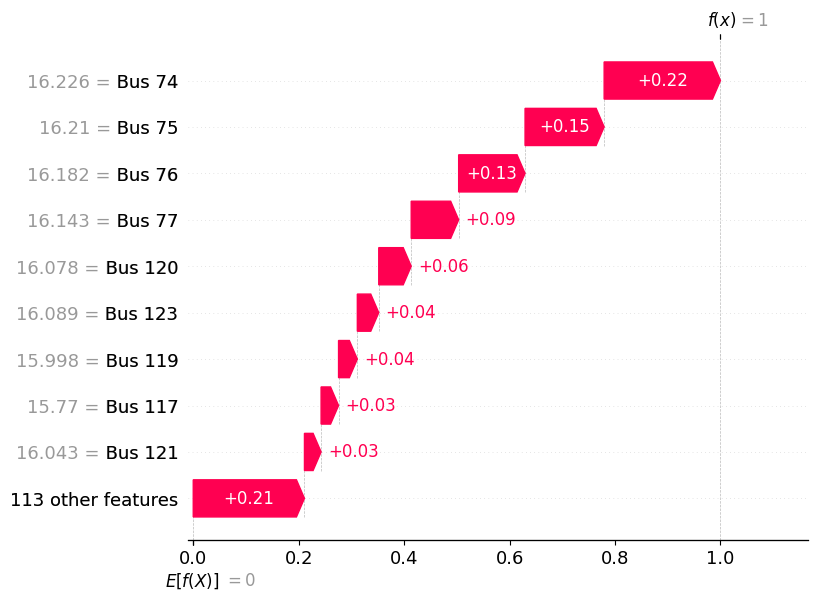

In [10]:
shap.plots.waterfall(shap_values.mean(0))

---